# Task 3 — NDVI Computation and Vegetation Analysis

**Study Area:** Rhine Gorge (Mittelrheintal), Germany  
**Formula:** NDVI = (B5 − B4) / (B5 + B4)

NDVI exploits the fact that healthy vegetation strongly absorbs Red light (for photosynthesis) and strongly reflects NIR (from leaf cell structure). Values range from −1 (water/bare rock) to +1 (dense forest).

In [2]:
!pip install rasterio numpy matplotlib shapely --quiet

In [3]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as mcm
import rasterio
from rasterio.crs import CRS
from rasterio.warp import transform_bounds, transform_geom
from rasterio.windows import from_bounds
from rasterio.mask import mask as rio_mask
from shapely.geometry import box, mapping, shape

print('Libraries loaded.')

Libraries loaded.


## Step 1 — Load config

In [4]:
CONFIG_PATH = '../data/landsat/band_paths.json'

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

aoi         = cfg['aoi']
AOI_MIN_LON = aoi['min_lon'];  AOI_MAX_LON = aoi['max_lon']
AOI_MIN_LAT = aoi['min_lat'];  AOI_MAX_LAT = aoi['max_lat']
CENTRE_LAT  = aoi['centre_lat'];  CENTRE_LON = aoi['centre_lon']
AREA_KM2    = aoi['area_km2']
SCENE_ID    = cfg['scene_id'];  SCENE_DATE  = cfg.get('scene_date', 'unknown')
BAND4_RED   = cfg['band4_red'];  BAND5_NIR  = cfg['band5_nir']
BAND3_GREEN = cfg['band3_green']; BAND2_BLUE = cfg['band2_blue']
LULC_PATH   = cfg.get('esri_lulc', {}).get('clipped_to_landsat', None)

os.makedirs('../data/outputs', exist_ok=True)
print(f'Scene: {SCENE_ID}  |  Date: {SCENE_DATE}  |  AOI: {AREA_KM2} km²')
print(f'LULC path: {LULC_PATH}')

Scene: LC81960252021153LGN00  |  Date: unknown  |  AOI: 50.0 km²
LULC path: ../data/esri_lulc/esri_lulc_clipped_to_landsat.tif


## Step 2 — Load Landsat bands

Applies Landsat Collection 2 Level-2 reflectance scaling: **ρ = DN × 0.0000275 − 0.2**. Fill pixels (DN < 7273) are masked to NaN. AOI is safely intersected with the raster boundary before masking so the loader never crashes on a slightly overshooting bbox.

In [ ]:
def load_band_clipped(filepath, min_lon, min_lat, max_lon, max_lat):
    """
    Load and clip one Landsat C2 L2 SR band to surface reflectance.
    Uses shapely intersection to safely handle
    AOI bbox that slightly overshoots the scene edge.
    """
    aoi_wgs84 = box(min_lon, min_lat, max_lon, max_lat)
    with rasterio.open(filepath) as src:
        aoi_native  = shape(transform_geom('EPSG:4326', src.crs.to_wkt(), mapping(aoi_wgs84)))
        raster_bbox = box(*src.bounds)
        aoi_safe    = aoi_native.intersection(raster_bbox)
        if aoi_safe.is_empty:
            raise ValueError(f'AOI does not overlap raster: {filepath}')
        clipped, _    = rio_mask(src, [mapping(aoi_safe)], crop=True, nodata=0)
        raw           = clipped[0].astype(np.float32)
        left, bottom, right, top = transform_bounds(
            CRS.from_epsg(4326), src.crs, min_lon, min_lat, max_lon, max_lat)
        win_transform = src.window_transform(from_bounds(left, bottom, right, top, src.transform))
        crs_out       = src.crs
    fill_mask   = (raw < 7273) | (raw > 65455)
    reflectance = np.clip(raw * 0.0000275 - 0.2, 0.0, 1.0)
    reflectance[fill_mask] = np.nan
    return reflectance, win_transform, crs_out

red_band,   TRANSFORM, CRS_UTM = load_band_clipped(BAND4_RED,   AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
nir_band,   _,         _       = load_band_clipped(BAND5_NIR,   AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
green_band, _,         _       = load_band_clipped(BAND3_GREEN, AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)
blue_band,  _,         _       = load_band_clipped(BAND2_BLUE,  AOI_MIN_LON, AOI_MIN_LAT, AOI_MAX_LON, AOI_MAX_LAT)

# Band shape safety trim — guards against minor pixel rounding differences
shapes = [red_band.shape, nir_band.shape, green_band.shape, blue_band.shape]
if len(set(shapes)) > 1:
    min_r = min(s[0] for s in shapes); min_c = min(s[1] for s in shapes)
    red_band, nir_band   = red_band[:min_r, :min_c],   nir_band[:min_r, :min_c]
    green_band, blue_band = green_band[:min_r, :min_c], blue_band[:min_r, :min_c]
    print(f'Bands trimmed to {min_r}×{min_c}')

valid_pct = 100.0 * np.sum(~np.isnan(red_band)) / red_band.size
print(f'Image size  : {red_band.shape[1]} × {red_band.shape[0]} px at 30 m')
print(f'Valid pixels: {valid_pct:.1f}%')

Image size  : 242 × 242 px at 30 m
Valid pixels: 95.5%


## Step 3 — Compute NDVI  *(Assessment 3a)*

In [6]:
with np.errstate(invalid='ignore', divide='ignore'):
    ndvi = (nir_band - red_band) / (nir_band + red_band)
ndvi = ndvi.astype(np.float32)

valid_ndvi = ndvi[~np.isnan(ndvi)]
veg_frac   = (valid_ndvi > 0.3).sum() / valid_ndvi.size * 100

print('NDVI Statistics:')
print(f'  Min    : {valid_ndvi.min():.4f}')
print(f'  Max    : {valid_ndvi.max():.4f}')
print(f'  Mean   : {valid_ndvi.mean():.4f}')
print(f'  Median : {np.median(valid_ndvi):.4f}')
print(f'  Std    : {valid_ndvi.std():.4f}')
print()
print(f'  Pixels with NDVI > 0.3 (vegetation): {veg_frac:.1f}%')
print()
print('Expected mean ~0.35–0.55 for a mixed forest/vineyard summer scene.')

NDVI Statistics:
  Min    : -0.9601
  Max    : 0.9635
  Mean   : 0.7511
  Median : 0.8448
  Std    : 0.2591

  Pixels with NDVI > 0.3 (vegetation): 94.1%

Expected mean ~0.35–0.55 for a mixed forest/vineyard summer scene.


## Step 4 — Display NDVI map with legend  *(Assessment 3b)*

`vmin=-1.0` is critical: the Rhine River has NDVI ≈ −0.6 to −0.9. With `vmin=-0.4` the river clips to the same colour as urban areas. Legend patches are sampled directly from the colormap so they match the map exactly.

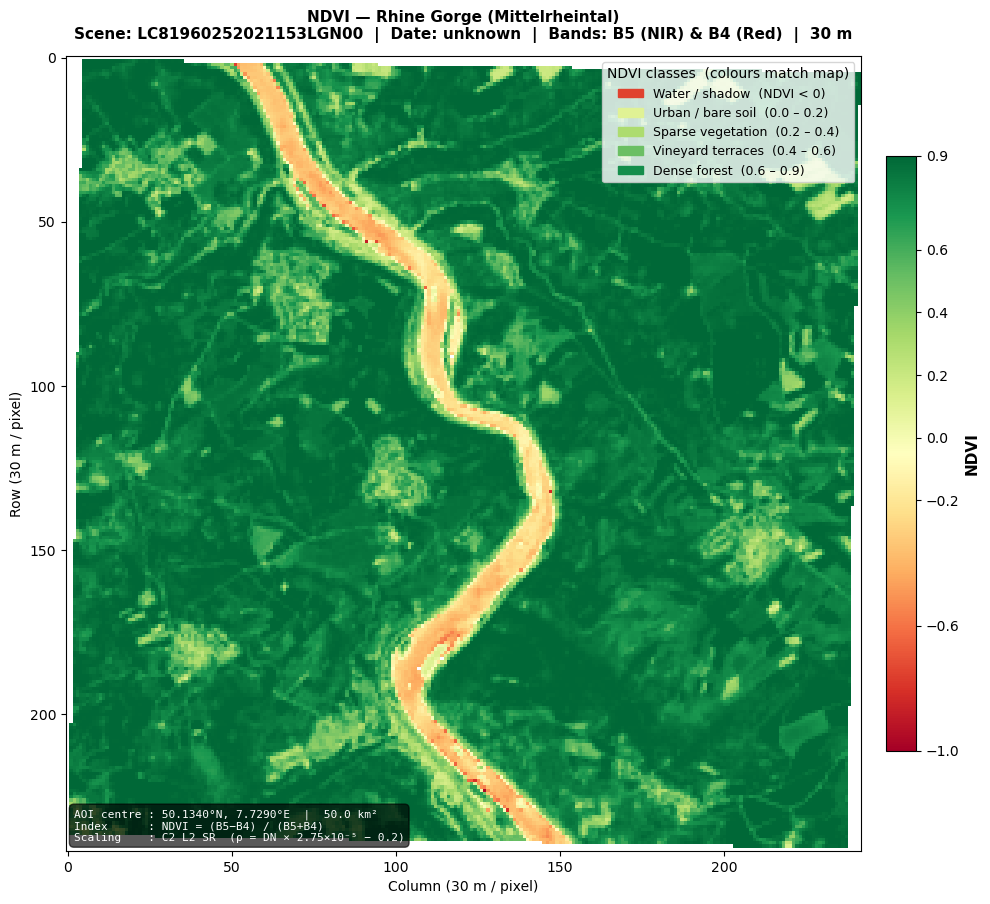

Saved → ndvi_rhine_gorge.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-1.0, vmax=0.9, interpolation='nearest')

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.set_label('NDVI', fontsize=11, fontweight='bold')
cbar.set_ticks([-1.0, -0.6, -0.2, 0.0, 0.2, 0.4, 0.6, 0.9])

ax.set_title(
    f'NDVI — Rhine Gorge (Mittelrheintal)\n'
    f'Scene: {SCENE_ID}  |  Date: {SCENE_DATE}  |  Bands: B5 (NIR) & B4 (Red)  |  30 m',
    fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Column (30 m / pixel)', fontsize=10)
ax.set_ylabel('Row (30 m / pixel)', fontsize=10)

_cmap = mcm.get_cmap('RdYlGn')
def _c(v): return _cmap(max(0.0, min(1.0, (v + 1.0) / 1.9)))

ax.legend(
    handles=[
        mpatches.Patch(color=_c(-0.75), label='Water / shadow  (NDVI < 0)'),
        mpatches.Patch(color=_c(0.10),  label='Urban / bare soil  (0.0 – 0.2)'),
        mpatches.Patch(color=_c(0.30),  label='Sparse vegetation  (0.2 – 0.4)'),
        mpatches.Patch(color=_c(0.50),  label='Vineyard terraces  (0.4 – 0.6)'),
        mpatches.Patch(color=_c(0.75),  label='Dense forest  (0.6 – 0.9)'),
    ],
    title='NDVI classes  (colours match map)', loc='upper right',
    fontsize=9, title_fontsize=10, framealpha=0.8)

ax.text(0.01, 0.01,
    f'AOI centre : {CENTRE_LAT:.4f}°N, {CENTRE_LON:.4f}°E  |  {AREA_KM2:.1f} km²\n'
    f'Index      : NDVI = (B5−B4) / (B5+B4)\n'
    f'Scaling    : C2 L2 SR  (ρ = DN × 2.75×10⁻⁵ − 0.2)',
    transform=ax.transAxes, fontsize=8, color='white', family='monospace',
    va='bottom', bbox=dict(facecolor='black', alpha=0.65, boxstyle='round,pad=0.4'))
plt.tight_layout()
plt.savefig('../data/outputs/ndvi_rhine_gorge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ndvi_rhine_gorge.png')

## Step 5 — NDVI class statistics

In [8]:
NDVI_CLASSES = [
    (-1.0, 0.0,  'Water / shadow'),
    ( 0.0, 0.2,  'Urban / bare soil'),
    ( 0.2, 0.4,  'Sparse vegetation'),
    ( 0.4, 0.6,  'Vineyard terraces'),
    ( 0.6, 1.0,  'Dense forest'),
]
pixel_area_km2 = (30 * 30) / 1e6
total_valid    = len(valid_ndvi)

print(f'NDVI Class Distribution  ({total_valid:,} px = {total_valid * pixel_area_km2:.2f} km²)')
print(f'\n{"NDVI Range":<16} {"Class":<24} {"Pixels":>8} {"Area km²":>10} {"Cover"}')
print('─' * 74)
for lo, hi, label in NDVI_CLASSES:
    mask  = (valid_ndvi >= lo) & (valid_ndvi < hi)
    count = mask.sum()
    pct   = 100.0 * count / total_valid
    print(f'[{lo:+.1f} → {hi:+.1f}]   {label:<24} {count:>8,} {count*pixel_area_km2:>10.3f}  {"█"*int(pct/2)} {pct:.1f}%')
print()
print(f'Vegetation fraction (NDVI > 0.3): {veg_frac:.1f}%')

NDVI Class Distribution  (55,901 px = 50.31 km²)

NDVI Range       Class                      Pixels   Area km² Cover
──────────────────────────────────────────────────────────────────────────
[-1.0 → +0.0]   Water / shadow              2,226      2.003  █ 4.0%
[+0.0 → +0.2]   Urban / bare soil             434      0.391   0.8%
[+0.2 → +0.4]   Sparse vegetation           1,587      1.428  █ 2.8%
[+0.4 → +0.6]   Vineyard terraces           3,593      3.234  ███ 6.4%
[+0.6 → +1.0]   Dense forest               48,061     43.255  ██████████████████████████████████████████ 86.0%

Vegetation fraction (NDVI > 0.3): 94.1%


## Step 6 — Three-panel comparison: True Color | NDVI | ESRI LULC

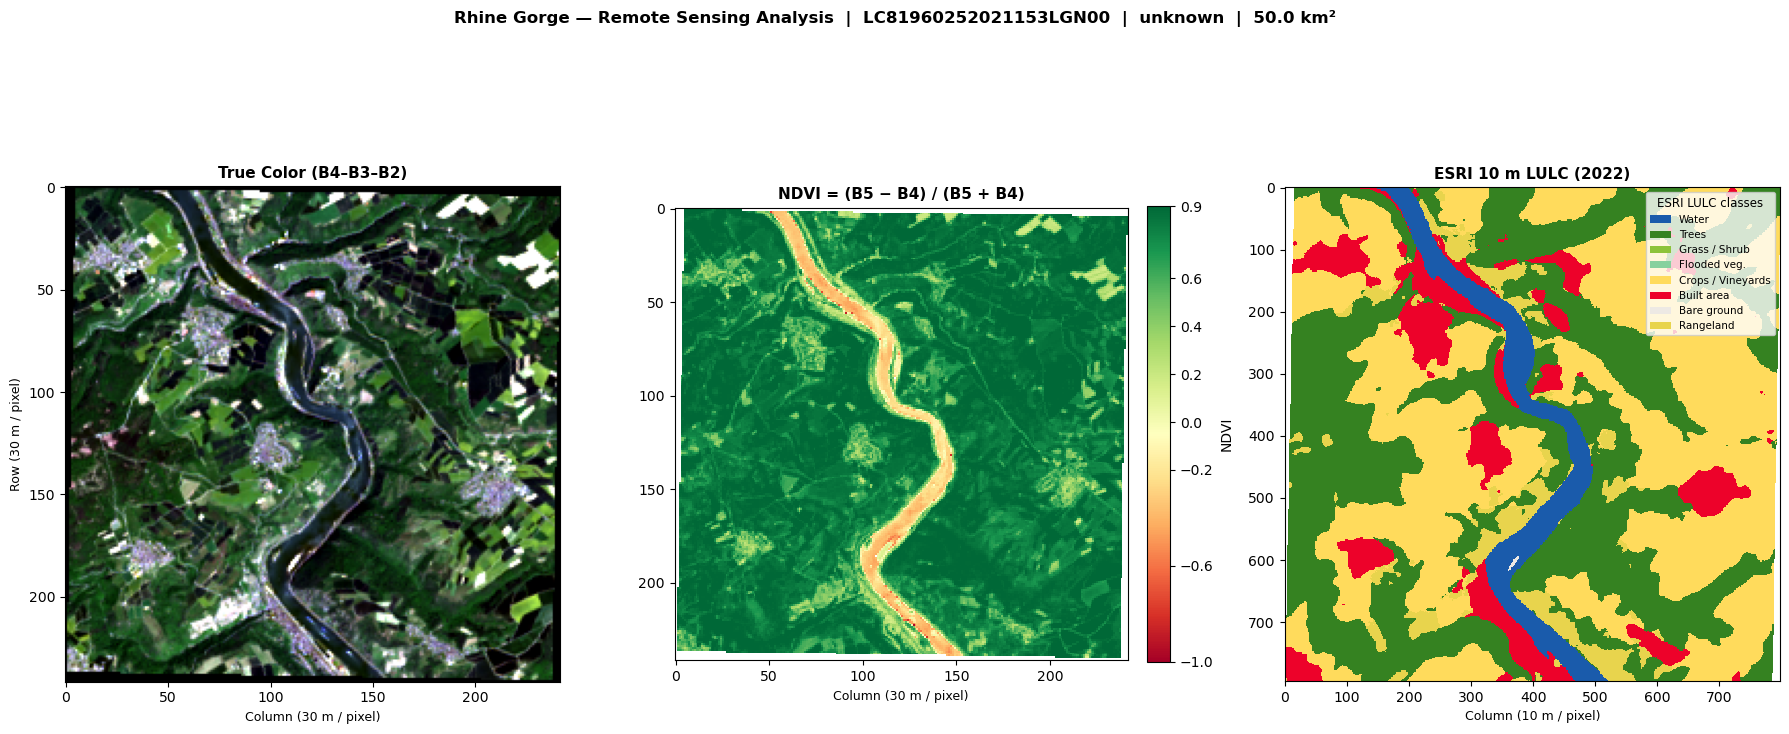

Saved → ndvi_comparison_panel.png


In [9]:
import matplotlib.colors as mcolors

def pct_stretch(band, lo=2, hi=98):
    v = band[~np.isnan(band)]
    p_lo, p_hi = np.percentile(v, lo), np.percentile(v, hi)
    return np.clip((band - p_lo) / (p_hi - p_lo + 1e-9), 0, 1)

rgb_image = np.nan_to_num(np.dstack([
    pct_stretch(red_band), pct_stretch(green_band), pct_stretch(blue_band)]), nan=0.0)

LULC_CLASSES_DISP = {
    1:  ('Water',              '#1A5BAB'),
    2:  ('Trees',              '#358221'),
    3:  ('Grass / Shrub',      '#8DC33B'),
    4:  ('Flooded veg.',       '#87D19E'),
    5:  ('Crops / Vineyards',  '#FFDB5C'),
    7:  ('Built area',         '#ED022A'),
    8:  ('Bare ground',        '#EDE9E4'),
    11: ('Rangeland',          '#E8D44D'),
}
MAX_CLASS   = 11
color_array = ['#000000'] * (MAX_CLASS + 1)
for c, (_, hx) in LULC_CLASSES_DISP.items(): color_array[c] = hx
LULC_CMAP2 = mcolors.ListedColormap(color_array)
LULC_NORM2 = mcolors.BoundaryNorm(boundaries=list(range(MAX_CLASS + 2)), ncolors=MAX_CLASS + 1)

lulc_arr = None
if LULC_PATH and os.path.exists(LULC_PATH):
    with rasterio.open(LULC_PATH) as src:
        lulc_arr = src.read(1).astype(float)
    lulc_arr[lulc_arr == 255] = np.nan

n_panels = 3 if lulc_arr is not None else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 8))

axes[0].imshow(rgb_image.astype(np.float32))
axes[0].set_title('True Color (B4–B3–B2)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Column (30 m / pixel)', fontsize=9)
axes[0].set_ylabel('Row (30 m / pixel)', fontsize=9)

im_ndvi = axes[1].imshow(ndvi, cmap='RdYlGn', vmin=-1.0, vmax=0.9, interpolation='nearest')
axes[1].set_title('NDVI = (B5 − B4) / (B5 + B4)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Column (30 m / pixel)', fontsize=9)
cbar2 = plt.colorbar(im_ndvi, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label('NDVI', fontsize=10)
cbar2.set_ticks([-1.0, -0.6, -0.2, 0.0, 0.2, 0.4, 0.6, 0.9])

if lulc_arr is not None:
    axes[2].imshow(lulc_arr, cmap=LULC_CMAP2, norm=LULC_NORM2, interpolation='nearest')
    axes[2].set_title('ESRI 10 m LULC (2022)', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Column (10 m / pixel)', fontsize=9)
    axes[2].legend(
        handles=[mpatches.Patch(facecolor=v[1], label=v[0]) for v in LULC_CLASSES_DISP.values()],
        title='ESRI LULC classes', loc='upper right', fontsize=7.5, title_fontsize=8.5, framealpha=0.8)

fig.suptitle(f'Rhine Gorge — Remote Sensing Analysis  |  {SCENE_ID}  |  {SCENE_DATE}  |  {AREA_KM2:.1f} km²',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/outputs/ndvi_comparison_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ndvi_comparison_panel.png')

## Step 7 — NDVI histogram

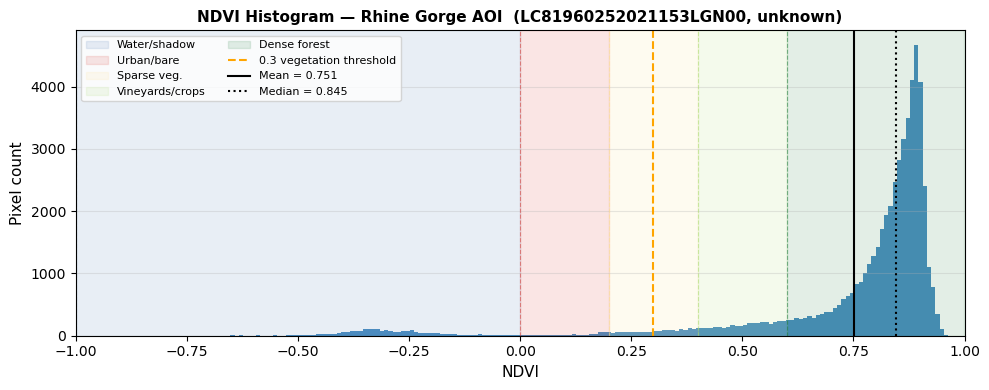

Saved → ndvi_histogram.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_ndvi, bins=200, color='#2c7bb6', edgecolor='none', alpha=0.85)

# Class shading zones
class_colors = ['#4575b4', '#d73027', '#fee08b', '#a6d96a', '#1a7837']
class_limits = [(-1.0, 0.0), (0.0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 1.0)]
class_labels = ['Water/shadow', 'Urban/bare', 'Sparse veg.', 'Vineyards/crops', 'Dense forest']
for (lo, hi), color, label in zip(class_limits, class_colors, class_labels):
    ax.axvspan(lo, hi, alpha=0.12, color=color, label=label)
    ax.axvline(lo, color=color, linewidth=0.8, linestyle='--', alpha=0.5)

# Vegetation threshold (from friend's project)
ax.axvline(0.3, color='orange', lw=1.5, ls='--', label='0.3 vegetation threshold')
ax.axvline(valid_ndvi.mean(),     color='black', lw=1.5, ls='-',  label=f'Mean = {valid_ndvi.mean():.3f}')
ax.axvline(np.median(valid_ndvi), color='black', lw=1.5, ls=':',  label=f'Median = {np.median(valid_ndvi):.3f}')

ax.set_xlabel('NDVI', fontsize=11); ax.set_ylabel('Pixel count', fontsize=11)
ax.set_title(f'NDVI Histogram — Rhine Gorge AOI  ({SCENE_ID}, {SCENE_DATE})', fontsize=11, fontweight='bold')
ax.set_xlim(-1.0, 1.0); ax.legend(fontsize=8, ncol=2, loc='upper left'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/outputs/ndvi_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → ndvi_histogram.png')

## Step 8 — Save NDVI GeoTIFF and update config

In [11]:
NDVI_TIFF = '../data/outputs/ndvi_rhine_gorge.tif'
ndvi_save = np.where(np.isnan(ndvi), -9999.0, ndvi).astype(np.float32)
with rasterio.open(NDVI_TIFF, 'w', driver='GTiff',
                   height=ndvi_save.shape[0], width=ndvi_save.shape[1],
                   count=1, dtype=np.float32,
                   crs=CRS_UTM, transform=TRANSFORM, nodata=-9999.0) as dst:
    dst.write(ndvi_save, 1)
print(f'NDVI GeoTIFF saved → {NDVI_TIFF}')
print(f'  Size: {ndvi_save.shape[1]} × {ndvi_save.shape[0]} px  |  CRS: {CRS_UTM}')

with open(CONFIG_PATH) as f: cfg = json.load(f)
cfg['ndvi'] = {'tif_path': NDVI_TIFF, 'formula': '(B5-B4)/(B5+B4)',
               'scaling': 'C2 L2 SR', 'nodata': -9999.0}
with open(CONFIG_PATH, 'w') as f: json.dump(cfg, f, indent=2)
print('Config updated.')

NDVI GeoTIFF saved → ../data/outputs/ndvi_rhine_gorge.tif
  Size: 242 × 242 px  |  CRS: EPSG:32632
Config updated.
